定义 State (图的状态)

---

State 是 LangGraph 的核心概念之一。它是图中所有节点之间共享的数据结构，可以理解为节点之间传递消息的"共享内存"。

在 LangGraph 中，State 有两种常见定义方式：

- **TypedDict**: 属于 typing 模块的一部分，仅提供静态类型检查，运行时不执行验证。轻量、无额外依赖，适合简单场景
- **Pydantic**: 第三方库，提供运行时数据验证和序列化功能。适合需要数据校验的复杂场景

State 中的每个字段都代表一个可以在节点之间传递的状态值。LangGraph 在执行时会自动管理 State 的更新和合并：

- 当节点返回一个字典时，LangGraph 会将返回的字典 **合并** 到当前 State 中
- 如果节点只返回了部分字段，其他字段保持不变
- 这种 "增量更新" 的设计让每个节点只需关注自己需要修改的字段

In [ ]:
from langchain_core.messages import AnyMessage
from typing_extensions import TypedDict

# 导入 AnyMessage (langchain 中所有消息类型的联合类型)
# 导入 TypedDict (用于定义带类型注解的字典)

# 定义 State 类: 这是整个图的"状态结构"，所有节点共享这个数据格式
# State 中的字段就是图在运行过程中会逐步修改和读取的状态值
class State(TypedDict):
    # messages: 存放对话消息列表，类型为 list[AnyMessage]
    # AnyMessage 是 langchain 消息类型的基类，包含 HumanMessage、AIMessage、SystemMessage 等
    messages: list[AnyMessage]
    # extra_field: 一个额外的整数字段，用于演示 State 可以包含多种类型的状态值
    extra_field: int

定义节点

---

In [ ]:
from langchain_core.messages import AIMessage

def node(state: State):
    messages = state["messages"]
    new_message = AIMessage("Hello, here's node_0")

    return {
        "messages": messages + [new_message],
        "extra_field": 0
    }

创建图

---

- 包含一个节点
- 使用 State 通信

In [ ]:
from langgraph.graph import StateGraph

graph = StateGraph(State)
graph.add_node(node)
graph.set_entry_point("node")
graph_builder = graph.compile()

查看节点与图结构

---

Mermaid 是基于文本的图标和可视化工具，允许通过简单的文本语法来创建复杂的图表和流程图

In [ ]:
from IPython.display import Image, display

display(Image(graph_builder.get_graph().draw_mermaid_png()))

调用

In [ ]:
from langchain_core.messages import HumanMessage

result = graph_builder.invoke({
    "messages": [HumanMessage("Hello, I'm a human")],
})

print(result)

使用 pretty_print 格式化显示输出

In [ ]:
for message in result["messages"]:
    message.pretty_print()

串行控制

---

In [ ]:
from typing_extensions import TypedDict
from IPython.display import Image, display
from langgraph.graph import START, StateGraph, END

class State(TypedDict):
    value_1: str
    value_2: str

def step_1(state: State):
    return {"value_1": "a",}

def step_2(state: State):
    current_value_1 = state["value_1"]
    return {"value_1": f"{current_value_1} + b",}

def step_3(state: State):
    return {"value_2": 10}

graph_builder = StateGraph(State)
graph_builder.add_node(step_1)
graph_builder.add_node(step_2)
graph_builder.add_node(step_3)

graph_builder.add_edge(START, "step_1")
graph_builder.add_edge("step_1", "step_2")
graph_builder.add_edge("step_2", "step_3")
graph_builder.add_edge("step_3", END)

graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
graph.invoke({"value_1": "c"})

分支控制

---

In [ ]:
import operator
from typing import Any, Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

class State(TypedDict):
    # Annotated 允许为类型提供额外的元数据而不影响类型检查对类型本身的理解
    aggregate: Annotated[list, operator.add]

def a(state: State):
    print(f"添加 a 到 {state['aggregate']}")
    return {"aggregate": ["a"]}

def b(state: State):
    print(f"添加 b 到 {state['aggregate']}")
    return {"aggregate": ["b"]}

def c(state: State):
    print(f"添加 c 到 {state['aggregate']}")
    return {"aggregate": ["c"]}

def d(state: State):
    print(f"添加 d 到 {state['aggregate']}")
    return {"aggregate": ["d"]}

graph_builder = StateGraph(State)
graph_builder.add_node(a)
graph_builder.add_node(b)
graph_builder.add_node(c)
graph_builder.add_node(d)

graph_builder.add_edge(START, "a")
graph_builder.add_edge("a", "b")
graph_builder.add_edge("a", "c")
graph_builder.add_edge("b", "d")
graph_builder.add_edge("c", "d")
graph_builder.add_edge("d", END)

graph = graph_builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

graph.invoke({"aggregate": []}, {"configurable": {"thread_id": "foo"}})

条件分支

---

In [ ]:
import operator
from typing import Annotated, Literal
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

class State(TypedDict):
    aggregate: Annotated[list, operator.add]

def a(state: State):
    print(f"添加 a 看到 {state['aggregate']}")
    return {"aggregate": ["a"]}

def b(state: State):
    print(f"添加 b 看到 {state['aggregate']}")
    return {"aggregate": ["b"]}

graph_builder = StateGraph(State)
graph_builder.add_node(a)
graph_builder.add_node(b)

def route(state: State) -> Literal["b", END]:
    if len(state["aggregate"]) < 7:
        return "b"
    else:
        return END

graph_builder.add_edge(START, "a")
graph_builder.add_conditional_edges("a", route)
graph_builder.add_edge("b", "a")
graph = graph_builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

graph.invoke({"aggregate": []})

循环

In [ ]:
import operator
from typing import Annotated, Literal
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

class State(TypedDict):
    aggregate: Annotated[list, operator.add]

def a(state: State):
    print(f"添加 a 看到 {state['aggregate']}")
    return {"aggregate": ["a"]}

def b(state: State):
    print(f"添加 b 看到 {state['aggregate']}")
    return {"aggregate": ["b"]}

def c(state: State):
    print(f"添加 c 看到 {state['aggregate']}")
    return {"aggregate": ["c"]}

def d(state: State):
    print(f"添加 d 看到 {state['aggregate']}")
    return {"aggregate": ["d"]}

graph_builder = StateGraph(State)
graph_builder.add_node(a)
graph_builder.add_node(b)
graph_builder.add_node(c)
graph_builder.add_node(d)

def route(state: State) -> Literal["b", END]:
    if len(state["aggregate"]) < 7:
        return "b"
    else:
        return END

graph_builder.add_edge(START, "a")
graph_builder.add_conditional_edges("a", route)
graph_builder.add_edge("b", "c")
graph_builder.add_edge("b", "d")
graph_builder.add_edge(["c", "d"], "a")
graph = graph_builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

graph.invoke({"aggregate": []})

图的运行时配置

---

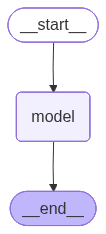

In [4]:
import operator

from typing import Annotated, Sequence
from typing_extensions import TypedDict

from langchain_deepseek import ChatDeepSeek
from langchain_openai import ChatOpenAI

import os

from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.runnables.config import RunnableConfig
from langgraph.graph import END, StateGraph, START

from IPython.display import Image, display

model_dpsk = ChatDeepSeek(
    model="deepseek-v4-flash",
    temperature=0,
    api_key=os.environ.get("DEEPSEEK_API_KEY"),
    base_url=os.environ.get("DEEPSEEK_API_BASE"),
)
model_openai = ChatOpenAI(
    model="deepseek-v4-pro",
    temperature=0,
    api_key=os.environ.get("OPENAI_API_KEY"),
    base_url=os.environ.get("OPENAI_API_BASE"),
)

# 定义要切换的模型
models = {
    "deepseek": model_dpsk,
    "openai": model_openai,
}

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]

def _call_model(state: AgentState, config: RunnableConfig):
    model_name = config["configurable"].get("model", "deepseek")
    model = models[model_name]
    response = model.invoke(state["messages"])
    return {"messages": [response]}

builder = StateGraph(AgentState)
builder.add_node("model", _call_model)
builder.add_edge(START, "model")
builder.add_edge("model", END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
# 调用 deepseek-v4-flash 模型
graph.invoke({"messages": [HumanMessage(content="你好")]})

{'messages': [HumanMessage(content='你好', additional_kwargs={}, response_metadata={}),
  AIMessage(content='你好！非常高兴能和你开始对话。无论你想讨论什么话题、询问任何问题，或者只是想随便聊聊，我都很乐意在这里陪你。今天有什么可以帮你的吗？😊', additional_kwargs={'refusal': None, 'reasoning_content': '好的，用户发来一个简单的问候“你好”。这是一个非常基础的社交开场。可能用户是想测试我是否在线，或者准备开始一个对话。深层需求是建立连接，确认回应，并开启交流。\n\n我需要给出友好、热情的回应，表明我准备好了，并主动提供帮助方向，引导用户说出具体需求。可以用开放式的提问邀请用户继续对话。'}, response_metadata={'token_usage': {'completion_tokens': 116, 'prompt_tokens': 5, 'total_tokens': 121, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 76, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 5}, 'model_provider': 'deepseek', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_058df29938_prod0820_fp8_kvcache_20260402', 'id': '3c9bdbcc-b40d-4d2d-9e66-dedaecd08fd3', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run-

增加运行时配置，动态切换模型

In [ ]:
# 调用 deepseek-v4-pro 模型
config = {"configurable": {"model": "openai"}}
graph.invoke({"messages": [HumanMessage(content="你好")]}, config=config)

{'messages': [HumanMessage(content='你好', additional_kwargs={}, response_metadata={}),
  AIMessage(content='你好呀！👋 很高兴见到你！\n\n我是 DeepSeek，一个由深度求索公司创造的 AI 助手。无论你有什么问题、想聊聊天，还是需要帮助完成任务，我都很乐意陪你一起探索和解决。\n\n今天有什么我可以帮你的吗？😊', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 124, 'prompt_tokens': 5, 'total_tokens': 129, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 66, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 5}, 'model_provider': 'openai', 'model_name': 'deepseek-v4-pro', 'system_fingerprint': 'fp_9954b31ca7_prod0820_fp8_kvcache_20260402', 'id': 'cee5e131-004d-4f8a-b92d-a258de8daf24', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019de2f2-3f12-76c0-a829-48c960e4ecc3-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 5, 'output_tokens': 12

MapReduce 并行执行

---

给定一个来自用户的一般主题，生成相关主题列表，为每个主题生成一个笑话，并从结果列表中选择最佳笑话。

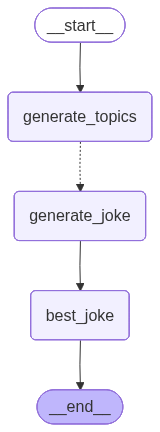

In [10]:
import os
import operator

from typing import Annotated, Sequence
from typing_extensions import TypedDict

from langchain_deepseek import ChatDeepSeek
from langchain_openai import ChatOpenAI

from langgraph.types import Send
from langgraph.graph import END, StateGraph, START

from pydantic import BaseModel, Field
from IPython.display import Image

# 模型和提示词
# 定义将使用的模型和提示词
subjects_prompt = """请生成 3 到 6 个与主题"{topic}"相关的具体例子（子类别），\
要求每个例子是一个独立的名词或短语，彼此不同，不要把"{topic}"本身作为答案。

例如，主题是"水果"，可以返回：苹果、香蕉、葡萄、西瓜。
现在请针对主题"{topic}"生成。"""
joke_pormpt = """生成一个关于{subject}的笑话。"""
best_joke_prompt = """以下是一些关于{topic}的笑话，选出最好的一个。返回最佳笑话的ID。

{jokes}"""

class Subjects(BaseModel):
    subjects: list[str] = Field(
        description="与给定主题相关的 3~6 个具体子类别/例子，每项是简短的名词短语，不能等于主题本身",
        min_length=3,
        max_length=6,
    )

class Joke(BaseModel):
    joke: str

class BestJoke(BaseModel):
    id: int = Field(description="最佳笑话的索引，从0开始", ge=0)

model_dpsk = ChatDeepSeek(
    model="deepseek-chat",
    temperature=0,
    api_key=os.environ.get("DEEPSEEK_API_KEY"),
    base_url=os.environ.get("DEEPSEEK_API_BASE"),
)

# 主图的整体状态
# 它将包含一个主题 (期望用户提供)
class OverallState(TypedDict):
    topic: str
    subjects: list
    # 用 operator.add
    # 因为想把从各个节点生成的所有笑话合并为一个列表，本质上是规约部分
    jokes: Annotated[list, operator.add]
    best_selected_joke: str

# 用于生成笑话
class JokeState(TypedDict):
    subject: str

# 用来生成笑话主题的函数
def generate_topics(state: OverallState):
    prompt = subjects_prompt.format(topic=state["topic"])
    response = model_dpsk.with_structured_output(Subjects).invoke(prompt)
    return {"subjects": response.subjects}

def generate_joke(state: JokeState):
    prompt = joke_pormpt.format(subject=state["subject"])
    response = model_dpsk.with_structured_output(Joke).invoke(prompt)
    return {"jokes": [response.joke]}

# 定义映射到生成的主题上的逻辑
# 将在图中使用这个作为边缘
def continue_to_jokes(state: OverallState):
    # 返回一个 Send 对象列表
    # 每个 Send 对象包含图中节点的名称以及要发送到该节点的状态
    return [Send("generate_joke", {"subject": s}) for s in state["subjects"]]

def best_joke(state: OverallState):
    jokes = "\n\n".join(state["jokes"])
    prompt = best_joke_prompt.format(topic=state["topic"], jokes=jokes)
    response = model_dpsk.with_structured_output(BestJoke).invoke(prompt)
    return {"best_selected_joke": state["jokes"][response.id]}

graph = StateGraph(OverallState)
graph.add_node("generate_topics", generate_topics)
graph.add_node("generate_joke", generate_joke)
graph.add_node("best_joke", best_joke)
graph.add_edge(START, "generate_topics")
graph.add_conditional_edges("generate_topics", continue_to_jokes, ["generate_joke"])
graph.add_edge("generate_joke", "best_joke")
graph.add_edge("best_joke", END)
app = graph.compile()

Image(app.get_graph().draw_mermaid_png())

In [11]:
for s in app.stream({"topic": "植物"}):
    print(s)

{'generate_topics': {'subjects': ['树木', '花卉', '蕨类', '多肉植物', '藤蔓植物', '草本植物']}}
{'generate_joke': {'jokes': ['为什么树不喜欢去学校？因为那里有太多"根"本问题，而且它们总是被"叶"务压得喘不过气来！🌳😄']}}
{'generate_joke': {'jokes': ['为什么向日葵总是很自信？因为它有最灿烂的笑脸，而且永远朝着阳光的方向！🌻']}}
{'generate_joke': {'jokes': ['为什么蕨类植物从来不说谎？因为它们天生就是卷（蕨）心菜！']}}
{'generate_joke': {'jokes': ['为什么多肉植物从来不吵架？因为它们都很有"肉"忍力，而且遇到问题总是"叶"着不说！']}}
{'generate_joke': {'jokes': ['为什么藤蔓植物不适合当程序员？因为它们总是喜欢缠绕（缠绕/缠绕代码），而且一遇到支撑物就依赖上了，完全不会独立站立！']}}
{'generate_joke': {'jokes': ['为什么薄荷总是很冷静？因为它有"薄荷"（薄荷的"薄"谐音"薄"凉）的个性！而且它还会说："别担心，我有清凉一夏的秘诀！"']}}
{'best_joke': {'best_selected_joke': '为什么树不喜欢去学校？因为那里有太多"根"本问题，而且它们总是被"叶"务压得喘不过气来！🌳😄'}}
